Para la correcta ejecución de este cuaderno, se procederá a importar los paquetes necesarios para ello.

In [2]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

**TAREA 1:** Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Para la correcta ejecución de esta tarea y de las restantes, se deberá de leer la imagen "mandril.jpg" proporcionada en esta práctica haciendo uso de las funciones de la librería OpenCV.

In [3]:
# Lee imagen de archivo
img = cv2.imread("mandril.jpg")

# Si hay lectura correcta
if img is not None:
    # Muestra dimensiones
    print(img.shape)

    # Recordar que OpenCV lee las imágenes almacenando en formato BGR, por lo que convertimos para visualizr de forma correcta a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
else:
    print("Imagen no encontrada")

(512, 512, 3)


Una vez se ha leído la imagen, esta se deberá convertir a escala de grises.

In [4]:
# Conversión de la imagen a niveles de grises de la imagen original en BGR
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gris.shape)


(512, 512)


Para esta tarea, se estará haciendo uso del detector de bordes _Canny_. Es por ello que, se deberán de ajustar los umbrales (tanto inferior como superior) con los que se trabajará para la imagen de entrada.

In [5]:
# Obtiene contornos con el operador de Canny
# Parámetros: imagen de entrada, umbral inferior, umbral superior
canny = cv2.Canny(gris, 100, 200)  # prueba a jugar con umbrales (entre 0 y 255)

En el guión de la práctica se proporciona el código para obtener el total de píxeles blancos en las columnas para, a partir de este, obtener el recuento de píxeles no nulos para las filas.

(0.0, 512.0)

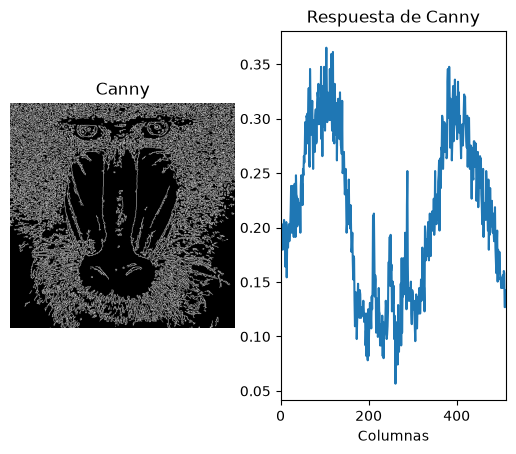

In [6]:
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)
#Cuenta el número de píxeles blancos (255) por columna
#Suma los valores de los pixeles por columna
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por columna
cols = col_counts[0] / (255 * canny.shape[0])

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols)
#Rango en x definido por las columnas
plt.xlim([0, canny.shape[1]])

De manera análoga al código anterior se procederá al cálculo de los píxeles blancos, en este caso para las filas de la imagen.

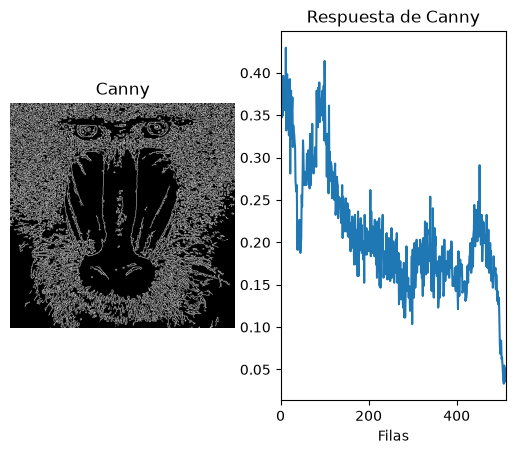

In [7]:
# Cuenta el número de píxeles blancos (255) por fila
white_pixels_per_row = cv2.reduce(canny, 255, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

# Porcentaje por fila
percentage_per_row = white_pixels_per_row / (255 * canny.shape[1])

# Muestra dicha cuenta gráficamente
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(percentage_per_row)
# Rango en x definido por filas
plt.xlim([0, canny.shape[0]])

plt.show()

Una vez hemos obtenido la gráfica con el recuento de filas, se procederá a representar a través del dibujo de primitivas, aquellas filas que superan el umbral de 0.9*maxrows_canny.

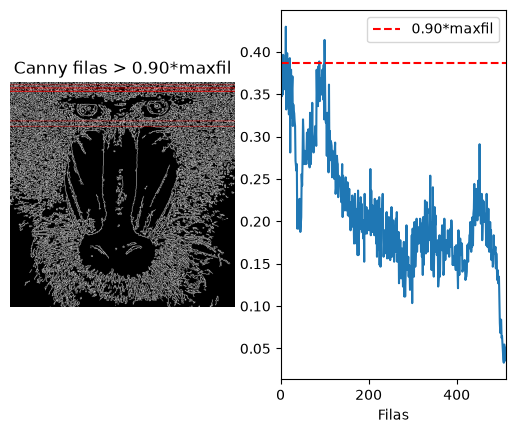

In [8]:
maxrows_canny = np.max(white_pixels_per_row)
umbralrows_canny = 0.90 * maxrows_canny
rows_sel_canny = np.where(white_pixels_per_row.flatten() > umbralrows_canny)[0]

# Imagen de Canny en color (BGR) para poder dibujar en rojo
canny_color = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
for f in rows_sel_canny:
    cv2.line(canny_color, (0, int(f)), (canny.shape[1] - 1, int(f)), (0, 0, 255), 1)

# Muestra la imagen resaltada y el plot con el umbral
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny filas > 0.90*maxfil")
plt.imshow(cv2.cvtColor(canny_color, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(percentage_per_row)
plt.axhline(umbralrows_canny / (255 * canny.shape[1]), color="r", linestyle="--", label="0.90*maxfil")
# Rango en x definido por filas
plt.xlim([0, canny.shape[0]])
plt.legend()

plt.show()

**TAREA 2:** Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

Con el objetivo de completar esta tarea, se deberá de aplicar primeramente un umbralizado a la imagen del mandril. En este caso se realizará el umbralizado sobre los bordes detectados haciendo uso del _operador Sobel_, a diferencia de la tarea anterior que se hizo con _Canny_

Para ello, se partirá del cálculo de Sobel proporcionado en el guión de esta práctica.

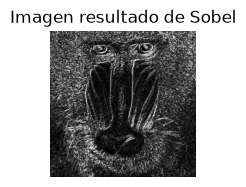

In [9]:
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Imagen resultado de Sobel')
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobel), cmap='gray') 
#plt.imshow(sobel, cmap='gray') #Prueba sin convertir escala
plt.show()

La visualización de la imagen con Sobel varía según como se procese, tal y como se evidencia en la ejecución de esta celda.

Tipo de datos, valor mínimo y máximo en sobel: float64, -594.0, 570.0
Tipo de datos, valor mínimo y máximo en sobel8: uint8, 0, 255
Tipo de datos, valor mínimo y máximo en sobel8np: uint8, 0, 254


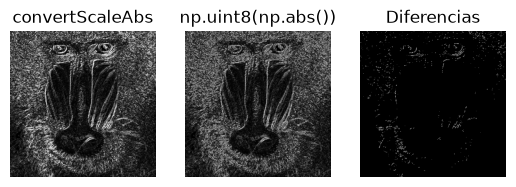

In [10]:
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel: {sobel.dtype}, {np.min(sobel)}, {np.max(sobel)}")

# Conversión a byte con openCV
sobel8 = cv2.convertScaleAbs(sobel)
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel8: {sobel8.dtype}, {np.min(sobel8)}, {np.max(sobel8)}")

# Conversión a byte con numpy
sobel8np = np.uint8(np.abs(sobel))
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel8np: {sobel8np.dtype}, {np.min(sobel8np)}, {np.max(sobel8np)}")

plt.figure()
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('convertScaleAbs')
plt.imshow(sobel8, cmap='gray') 

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('np.uint8(np.abs())')
plt.imshow(sobel8np, cmap='gray') 

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Diferencias')
plt.imshow(cv2.absdiff(sobel8,sobel8np), cmap='gray') 

plt.show()

Para la correcta compleción de esta tarea, se hará uso de la imagen convertida con _numpy_. De esta forma, se procede a continuación a la umbralización.

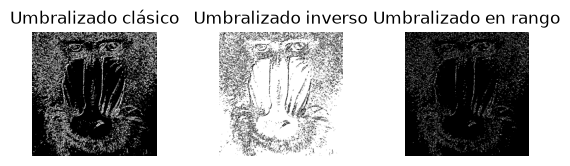

In [11]:
#Define valor umbral
valorUmbral = 100 #Prueba otros valores
#Obtiene imagen umbralizada para dicho valor definido
_, sobelUmbralizado = cv2.threshold(sobel8np, valorUmbral, 255, cv2.THRESH_BINARY)

#El umbralizado inverso, los valores menores que el umbral se muestran en blanco
_, sobelUmbralizadoInverso = cv2.threshold(sobel8np, valorUmbral, 255, cv2.THRESH_BINARY_INV)

#Valores en rango determinado por dos umbrales
imagenEnRango = cv2.inRange(sobel8np, 150, 200)

plt.figure()
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('Umbralizado clásico')
plt.imshow(sobelUmbralizado, cmap='gray')

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('Umbralizado inverso')
plt.imshow(sobelUmbralizadoInverso, cmap='gray')

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Umbralizado en rango')
plt.imshow(imagenEnRango, cmap='gray')

plt.subplots_adjust(wspace=0.5)

plt.show()

Es importante tener en cuenta que, si se procediera a realizar el presente conteo con la imagen convertida con _OpenCV_, los resultados variarían mínimamente. Asimismo, se procederá a realizar el conteo de columnas de la imagen de Sobel convertida previamente con _numpy_.

(0.0, 512.0)

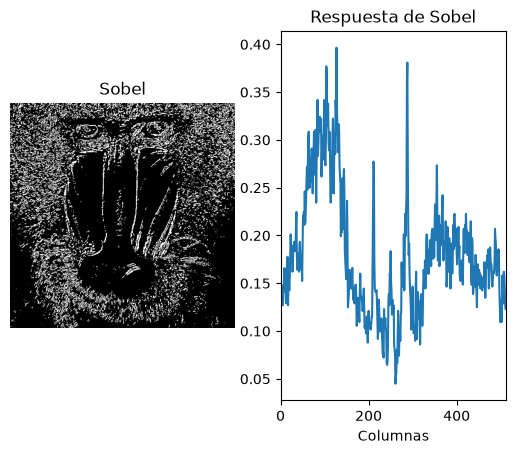

In [12]:
#Cuenta el número de píxeles blancos (255) por columna
#Suma los valores de los pixeles por columna
col_counts_sobel = cv2.reduce(sobelUmbralizado, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por columna
cols_sobel = col_counts_sobel[0] / (255 * sobelUmbralizado.shape[0])

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Sobel")
plt.imshow(sobelUmbralizado, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Sobel")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols_sobel)
#Rango en x definido por las columnas
plt.xlim([0, sobelUmbralizado.shape[1]])

De igual manera, se procederá a realizar también el conteo de las filas de píxeles no nulos para Sobel.

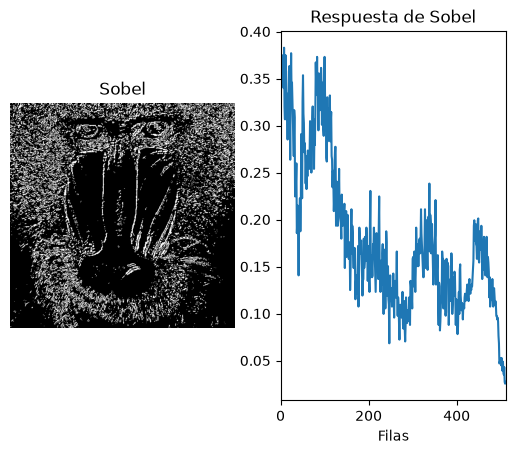

In [13]:
# Obtiene contornos con el operador de Canny
# Parámetros: imagen de entrada, umbral inferior, umbral superior
#canny = cv2.Canny(gris, 100, 200)  # prueba a jugar con umbrales (entre 0 y 255)

# Cuenta el número de píxeles blancos (255) por fila
rows_count_sobel = cv2.reduce(sobelUmbralizado, 255, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

# Porcentaje por fila
rows_sobel = rows_count_sobel / (255 * sobelUmbralizado.shape[1])

# Muestra dicha cuenta gráficamente
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Sobel")
plt.imshow(sobelUmbralizado, cmap="gray")


plt.subplot(1, 2, 2)
plt.title("Respuesta de Sobel")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows_sobel)
# Rango en x definido por filas
plt.xlim([0, sobelUmbralizado.shape[0]])

plt.show()

Finalmente, con objeto de realizar una comparativa entre los resultados obtenidos al aplicar Canny y Sobel, se representará gráficamente la comparativa entre los resultados obtenidos para las filas y columnas en cada una de las imágenes. 

Máximo de filas: 49980, Máximo de columnas: 51765


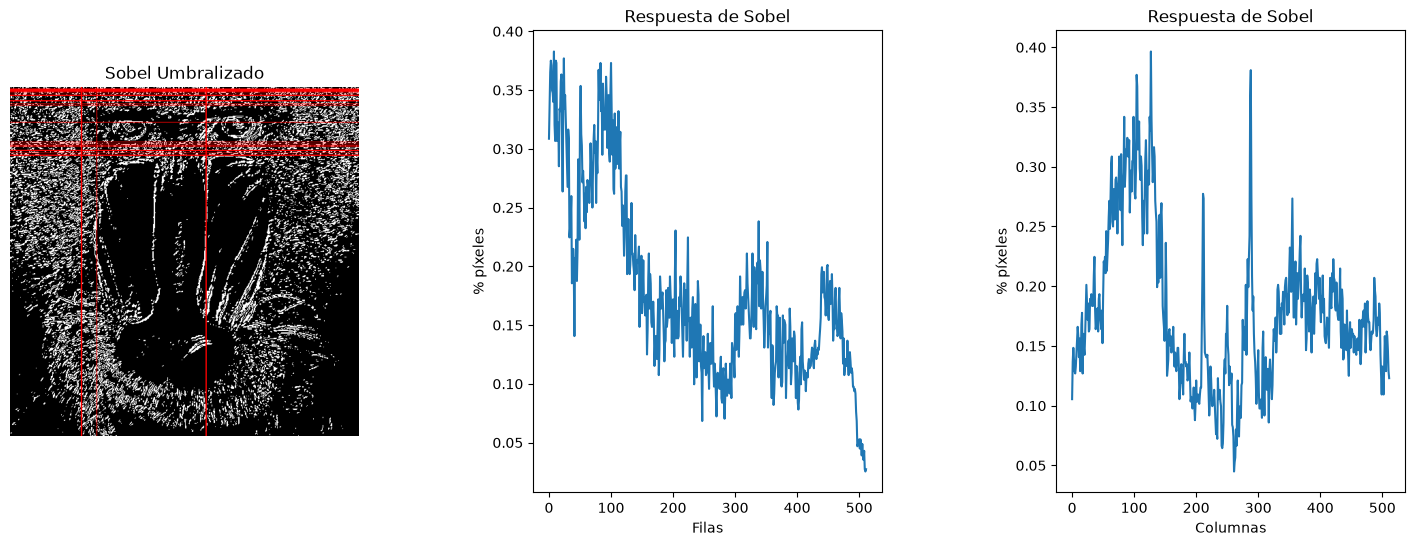

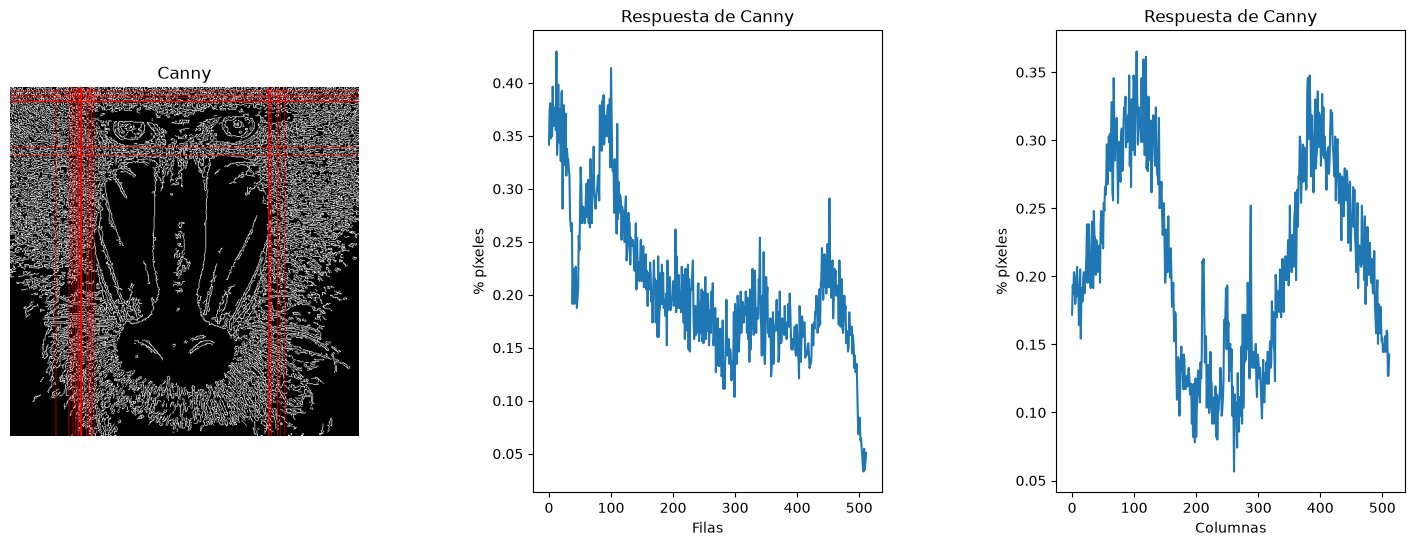

In [14]:
maxcols_canny = np.max(col_counts)

maxrows_sobel = np.max(rows_count_sobel)
maxcols_sobel = np.max(col_counts_sobel)

print(f"Máximo de filas: {maxrows_sobel}, Máximo de columnas: {maxcols_sobel}")

cols_sel_canny = np.where(col_counts.flatten() > 0.90 * maxcols_canny)[0] # Columnas en el umbral de Canny

rows_sel_sobel = np.where(rows_count_sobel.flatten() > 0.90 * maxrows_sobel)[0]
cols_sel_sobel = np.where(col_counts_sobel.flatten() > 0.90 * maxcols_sobel)[0]

# Imagenés de Canny y Sobel en color (BGR) para poder dibujar en rojo
canny_color = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
sobel_color = cv2.cvtColor(sobelUmbralizado, cv2.COLOR_GRAY2BGR)

for f in rows_sel_canny:
    cv2.line(canny_color, (0, int(f)), (canny.shape[1] - 1, int(f)), (0, 0, 255), 1)

for c in cols_sel_canny:
    cv2.line(canny_color, (int(c), 0), (int(c), canny.shape[0] - 1), (0, 0, 255), 1)

for f in rows_sel_sobel:
    cv2.line(sobel_color, (0, int(f)), (sobelUmbralizado.shape[1] - 1, int(f)), (0, 0, 255), 1)

for c in cols_sel_sobel:
    cv2.line(sobel_color, (int(c), 0), (int(c), sobelUmbralizado.shape[0] - 1), (0, 0, 255), 1)


# Comparativa entre las columnas y filas de Sobel
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.axis("off")
plt.title("Sobel Umbralizado")
plt.imshow(cv2.cvtColor(sobel_color, cv2.COLOR_BGR2RGB))

plt.subplot(1, 3, 2)
plt.title("Respuesta de Sobel")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows_sobel)

plt.subplot(1, 3, 3)
plt.title("Respuesta de Sobel")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols_sobel)

plt.subplots_adjust(wspace=0.5)

plt.show()

# Comparativa entre las columnas y filas de Canny

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(cv2.cvtColor(canny_color, cv2.COLOR_BGR2RGB))

plt.subplot(1, 3, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(percentage_per_row)

plt.subplot(1, 3, 3)
plt.title("Respuesta de Canny")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols)

plt.subplots_adjust(wspace=0.5)

plt.show()

Si se observan las dos comparativas obtenidas, se puede apreciar como hay más presencia de filas que superan el umbral en la imagen procesada con Sobel. En cambio para el caso de las columnas es al contrario: en la imagen obtenida tras la ejecución de Canny se han obtenido mayor número de columnas sobre el umbral establecido que de filas.

**TAREA 3:** Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

Para la correcta compleción de esta tarea se propone que el alumno realice un demostrador inspirado en alguno de los 3 vídeos sugeridos.

Con el fin de resolver esta tarea, se ha propuesto un demostrador inspirado en [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared). Para ello, se ha reaprovechado el umbralizado realizado en el guión práctico para que, cuando se detecte movimiento en la escena, se generen burbujas en la misma.

In [17]:
vid = cv2.VideoCapture(0)

# Fondo
# Inicializa la sustracción del fondo con mezcla de gaussianas y detección de sombras
eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50, detectShadows=True)

# Cada burbuja es una lista: [x, y, radio, velocidad]
burbujas = []

while(True):
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        # Aplica efecto espejo sobre la entrada
        framem = cv2.flip(frame, 1)

        # Máscara de movimiento (255 = movimiento, 127 = sombra)
        objetos = eliminadorFondo.apply(framem)

        # Umbralizado: las sombras (127) pasan a 0 y el movimiento real queda en 255
        _, umbral = cv2.threshold(objetos, 200, 255, cv2.THRESH_BINARY)

        # Coordenadas de los píxeles en movimiento
        ys, xs = np.where(umbral == 255)

        # Si hay movimiento, crea burbujas en puntos al azar de la máscara
        if len(xs) > 300:
            for i in range(3):
                n = random.randrange(len(xs))
                burbujas.append([xs[n], ys[n], random.randint(8, 30), random.randint(1, 4)])

        # Mueve y dibuja las burbujas
        for b in burbujas:
            b[1] -= b[3]    # sube
            b[0] += random.randint(-2, 2)    # se balancea
            cv2.circle(framem, (int(b[0]), int(b[1])), b[2], (255, 255, 200), 2)

        # Elimina las burbujas que salen por arriba
        burbujas = [b for b in burbujas if b[1] > 0]

        # Muestra resultado
        cv2.imshow('Fotograma', framem)
        # Muestra el umbralizado
        cv2.imshow('Umbralizado', umbral)

    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break

# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()